[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JeremieJakubowicz/xhec-advanced-ai-2026/blob/main/Session2/Session2a-From-Table-To-Network.ipynb)

# Session 2 (part A) — From the lookup table to the neural network

**Advanced AI: Language Models & Agents** · X-HEC · Fall 2026 · Author: Jérémie Jakubowicz

Session 1 ended with a table of counts that had two defects: it **recites** as soon as the memory is long, and it is **mute** on any context it has never seen. This session replaces the table by a function that *models* the probability of the next token instead of looking it up, and shows, with a single measurement, that the function does better. Part B then gives the function a memory that reaches further back, and measures how far it really goes.

**What you will take away from this part**

1. **Self-supervision.** Predicting the next token is a supervised problem whose labels are free: the text is its own teacher.
2. **One measurement.** The *surprise* of the model on unseen text, read as a training loss, as a perplexity, or in bits per character. Every model in this course, up to GPT-5-class ones, is trained to make that number small.
3. **Table versus model.** The table is a nearest-neighbour method: it answers only for contexts it has seen, exactly. A neural network is a regression: it answers for any context, by similarity. A convolutional network is the simplest one that does this well.

In [ ]:
# On Google Colab, run this cell first, on a GPU runtime (Runtime > Change runtime type > T4 GPU).
# torch, pandas, matplotlib and scikit-learn are preinstalled there; tokenizers is not.
# Locally, see the README of this folder for the full list of dependencies.
%pip install -q tokenizers

## 1. Setting: the same corpus, the same tokens as session 1

Same Victor Hugo corpus, split once and for all: the first 85 % to train on, the next 5 % to make decisions (the *validation* set), the last 10 % to measure and never touch otherwise (the *test* set). The tokenizer is a byte-level BPE with 8,000 tokens, built with the same recipe as in session 1 but retrained on the training split only, so that the test text stays unseen by every part of the pipeline, and saved to a file: every model of this session, and of the next one, reads exactly the same tokens.

In [2]:
import os, math, time, random, urllib.request, warnings
warnings.filterwarnings("ignore")
from collections import Counter, defaultdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from tokenizers import Tokenizer

BASE = "https://raw.githubusercontent.com/JeremieJakubowicz/xhec-advanced-ai-2026/main/"

def fetch(relative_path):
    """Download a file from the course repository once, then reuse the local copy."""
    local = os.path.basename(relative_path)
    if not os.path.exists(local):
        print("downloading", relative_path)
        urllib.request.urlretrieve(BASE + relative_path, local)
    return local

hugo = open(fetch("data/hugotexts.txt"), encoding="utf-8").read()
tok = Tokenizer.from_file(fetch("data/hugo_bpe_8k.json"))
V = tok.get_vocab_size()

a, b = int(0.85 * len(hugo)), int(0.90 * len(hugo))
text = dict(train=hugo[:a], val=hugo[a:b], test=hugo[b:])
encode = lambda s: [i for j in range(0, len(s), 200_000) for i in tok.encode(s[j:j + 200_000]).ids]
data = {k: torch.tensor(encode(v)) for k, v in text.items()}
chars_per_token = {k: len(text[k]) / len(data[k]) for k in data}

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"vocabulary {V:,} tokens | " + " | ".join(f"{k}: {len(v):,} tokens" for k, v in data.items()) + f" | device: {device}")

vocabulary 8,000 tokens | train: 3,425,394 tokens | val: 203,495 tokens | test: 414,940 tokens | device: mps


## 2. Self-supervision: the text is its own teacher

Supervised learning needs pairs $(x, y)$. For spam detection, someone had to label emails. For a language model, the pairs are already there: take any position in the text, $x$ is what precedes it, $y$ is the token that follows. A 3.4-million-token corpus is 3.4 million labelled examples, for free. This is called **self-supervision**, and it is the reason language models could be trained on the whole web, which no one could have labelled.

A training *batch* is a handful of random windows of the text. A window of $T$ tokens gives $T$ examples at once: at every position, the target is the next token.

In [3]:
def batch(split, n, length):
    d = data[split]
    ix = torch.randint(0, len(d) - length - 1, (n,))
    x = torch.stack([d[i:i + length] for i in ix])
    y = torch.stack([d[i + 1:i + length + 1] for i in ix])          # y is x shifted by one token
    return x.to(device), y.to(device)

x, y = batch("train", 1, 12)
for i in range(4):
    print(f"context: {tok.decode(x[0, :i + 1].tolist())!r:45} -> next token: {tok.decode([y[0, i].item()])!r}")

context: ' matière'                                    -> next token: ';'
context: ' matière;'                                   -> next token: '\n'
context: ' matière;\n'                                 -> next token: 'C'
context: ' matière;\nC'                                -> next token: "'"


## 3. One measurement for the whole course: surprise

Session 1 measured memorisation with ad hoc quantities. From now on we use the one that every language model is trained on. For each token of a text the model never saw, take the probability $p$ it assigned to the token that actually came, and compute $-\log p$: zero if the model was sure, large if it did not expect it. Average over the text. That is the model's **surprise**, and it is one number under three names:

| name                                | formula                                                    | reads as                                                        |
| ----------------------------------- | ---------------------------------------------------------- | --------------------------------------------------------------- |
| training loss (what PyTorch prints) | $-\ln p$, averaged per token                               | nats per token                                                  |
| perplexity                          | $e^{\text{loss}}$                                          | the number of equally likely tokens the model hesitates between |
| bits per character                  | $-\log_2 p$, summed, divided by the number of *characters* | comparable across tokenizers                                    |

The first two depend on the tokenizer: a model whose tokens are bigger is more surprised per token without being worse. Dividing by characters removes that dependence, which is why the last column is the one we use to rank models, including against the character table of session 1 and, later, against models that come with their own vocabulary. It is also the unit of Shannon's experiment with human guessers.

In [4]:
def surprise(model, split="test", window=128, warm=64, limit=None, batch_size=64):
    """Average -log p of the next token on a held-out split, in nats per token. Windows overlap by `warm` tokens
    and only their last `window - warm` tokens are scored, so that every scored token sees at least 64 tokens of context."""
    d = data[split][:limit]
    starts = range(0, len(d) - window - 1, window - warm)
    model.eval(); nll, n = 0.0, 0
    with torch.no_grad():
        for b0 in range(0, len(starts), batch_size):
            idx = starts[b0:b0 + batch_size]
            x = torch.stack([d[i:i + window] for i in idx]).to(device)
            y = torch.stack([d[i + 1:i + window + 1] for i in idx]).to(device)
            losses = F.cross_entropy(model(x).reshape(-1, V), y.reshape(-1), reduction="none").reshape(len(idx), window)
            nll += losses[:, warm:].sum().item(); n += len(idx) * (window - warm)
    model.train()
    return nll / n

def report(name, nats, split="test"):
    return dict(model=name, loss=round(nats, 3), perplexity=round(math.exp(nats), 1),
                bits_per_char=round(nats / math.log(2) / chars_per_token[split], 3))

uniform = math.log(V)                     # a model that assigns 1/V to every token
scoreboard = [report("uniform guess", uniform)]
pd.DataFrame(scoreboard)

,model,loss,perplexity,bits_per_char
0,uniform guess,8.987,8000.0,3.983


### 3.1 The table, scored with the same ruler

Session 1's table had a defect we did not measure: on an unseen context it has no answer at all, and a probability of zero is an infinite surprise. The standard fix, *smoothing*, mixes the counts of a long context with the counts of shorter ones, so that the table always answers something. With that fix the table is a legitimate model and it goes on the scoreboard. This is the best table we could build on this corpus: memory 2, mixing weight chosen on the validation set; memory 3 does not help.

**The formula.** Write $c(h, w)$ for the number of times token $w$ followed the context $h$ in the training text, and $c(h) = \sum_w c(h, w)$ for the number of times $h$ occurred at all. Let $h_k$ be the last $k$ tokens before the position to predict, so that $h_0$ is the empty context and $h_m$ the full memory. Start from the uniform guess and climb from the shortest context to the longest:

$$q_{-1}(w) = \frac{1}{V}, \qquad q_k(w) = \frac{c(h_k, w) + \alpha \, q_{k-1}(w)}{c(h_k) + \alpha} \quad \text{for } k = 0, 1, \dots, m .$$

The prediction of the table with memory $m$ is $q_m(w)$. Each step is a weighted average of two distributions, the raw frequency at this order and the estimate of the order below:

$$q_k(w) = \underbrace{\frac{c(h_k)}{c(h_k) + \alpha}}_{\text{trust in the counts}} \cdot \frac{c(h_k, w)}{c(h_k)} \;+\; \underbrace{\frac{\alpha}{c(h_k) + \alpha}}_{\text{fall-back}} \cdot q_{k-1}(w) .$$

Read it in the two extreme cases. A context seen many times, $c(h_k) \gg \alpha$: the raw frequency wins, the table behaves as in session 1. A context never seen, $c(h_k) = 0$: the estimate is exactly the one of the shorter context, so the table always has an answer and no probability is ever zero. In between, $\alpha$ acts as a number of *pseudo-observations* borrowed from the shorter context. It is the only parameter, and it was chosen on the validation set ($\alpha = 64$ here). As $\alpha \to 0$ we recover the raw table with its holes; as $\alpha \to \infty$ the counts are ignored and every $q_k$ is the uniform guess. Since each $q_k$ is a mixture of two distributions, it sums to 1.

This estimator is the simplest member of a family that was the state of the art of language modelling for thirty years. Its most refined member, Kneser-Ney smoothing, discounts every count by a fixed amount and weights the fall-back by the number of *different* contexts a token appears in. The idea never changes: when the evidence for a long context is thin, borrow from a shorter one. The code below is the recursion above, computed on the fly for each token to score.

In [5]:
class SmoothedTable:
    """Interpolated counts: p(w | last k tokens) mixes the count for k with the estimate for k - 1, down to 1/V."""
    def __init__(self, ids, memory, alpha):
        self.memory, self.alpha = memory, alpha
        self.counts = [defaultdict(Counter) for _ in range(memory + 1)]
        for k in range(memory + 1):
            for i in range(k, len(ids)):
                self.counts[k][tuple(ids[i - k:i])][ids[i]] += 1
        self.totals = [{c: sum(n.values()) for c, n in self.counts[k].items()} for k in range(memory + 1)]

    def prob(self, context, w):
        p = 1.0 / V
        for k in range(self.memory + 1):
            ctx = tuple(context[len(context) - k:]) if k else ()
            c, n = self.counts[k].get(ctx, {}).get(w, 0), self.totals[k].get(ctx, 0)
            p = (c + self.alpha * p) / (n + self.alpha)
        return p

    def surprise(self, split="test", limit=None):
        ids = data[split][:limit].tolist(); nll = 0.0
        for i in range(self.memory, len(ids)):
            nll -= math.log(self.prob(ids[i - self.memory:i], ids[i]))
        return nll / (len(ids) - self.memory)

t0 = time.time()
table = SmoothedTable(data["train"].tolist(), memory=2, alpha=64.0)
scoreboard.append(report("smoothed table, memory 2", table.surprise("test", limit=100_000)))
print(f"built and scored in {time.time() - t0:.0f}s")
pd.DataFrame(scoreboard)

built and scored in 4s


,model,loss,perplexity,bits_per_char
0,uniform guess,8.987,8000.0,3.983
1,"smoothed table, memory 2",4.545,94.1,2.014


From 8,000 equally likely tokens to a perplexity below 100: two tokens of context already remove most of the uncertainty, which is Shannon's point again. Now let us see whether a *function* can beat the table.

## 4. From nearest neighbours to regression

Think of the table as a **nearest-neighbour** method with a very strict notion of neighbour: two contexts are neighbours only if they are *identical*. `le roi de` and `la reine de` share nothing, and a context seen once is answered from that single occurrence. A neural network replaces this by a **regression**: contexts are turned into vectors, similar contexts get similar vectors, and one function maps vectors to a distribution over the next token. What the model learns on `le roi de` transfers to `la reine de`. The ingredient that makes it possible is the **embedding**: every token gets a learned vector, and the words the network needs to treat alike end up close.

### 4.1 The model: a convolutional network that reads a short window

The first neural language model (Bengio, 2003) concatenated the vectors of the last few tokens and applied a hidden layer. A **convolution** does the same thing more economically: one small filter reads three consecutive token vectors and produces a new vector, and *the same filter is applied at every position* of the text. Stack four such layers and the vector at a position has seen the nine tokens before it. Two details, standard in modern networks: each layer *adds* its result to its input (a *residual* connection, which makes deep stacks trainable), and the filter output is multiplied by a *gate* between 0 and 1 (which lets the layer decide how much to write).

The filter only ever looks backwards (a *causal* convolution): position $t$ must not see token $t+1$, which is what it has to predict.

In [6]:
class LocalCNN(nn.Module):
    """Causal convolutions with kernel 3: the prediction at a position sees the last 1 + 2 * layers tokens."""
    def __init__(self, d=256, layers=4, kernel=3, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(V, d)                                             # one learned vector per token
        self.convs = nn.ModuleList([nn.Conv1d(d, 2 * d, kernel) for _ in range(layers)])
        self.norm, self.drop, self.kernel = nn.LayerNorm(d), nn.Dropout(dropout), kernel
        self.receptive_field = 1 + (kernel - 1) * layers
        nn.init.normal_(self.emb.weight, std=d ** -0.5)

    def forward(self, x):                                                         # x: (batch, T) token ids
        h = self.drop(self.emb(x)).transpose(1, 2)                                # (batch, d, T)
        for conv in self.convs:
            u, g = conv(F.pad(h, (self.kernel - 1, 0))).chunk(2, dim=1)          # pad on the left: causal
            h = h + self.drop(u * torch.sigmoid(g))                               # residual, gated
        return self.norm(h.transpose(1, 2)) @ self.emb.weight.T                   # (batch, T, V): one logit per token

model = LocalCNN().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f} M parameters, sees {model.receptive_field} tokens back")

3.6 M parameters, sees 9 tokens back


**The model, written out.** Let $x_1, \dots, x_T$ be the tokens of a window and $E \in \mathbb{R}^{V \times d}$ the embedding matrix. The input of the network is the sequence of vectors $h^{(0)}_t = E_{x_t}$. The network stacks $L$ identical layers, each with a filter of size $K$.

*One causal, gated, residual layer.* Layer $\ell$ owns a filter of $K$ matrices $W^{(\ell)}_0, \dots, W^{(\ell)}_{K-1} \in \mathbb{R}^{2d \times d}$ and a bias $b^{(\ell)} \in \mathbb{R}^{2d}$. At every position $t$ it computes

$$a^{(\ell)}_t = b^{(\ell)} + \sum_{j=0}^{K-1} W^{(\ell)}_j \, h^{(\ell-1)}_{t-j}, \qquad a^{(\ell)}_t = \begin{pmatrix} u^{(\ell)}_t \\ g^{(\ell)}_t \end{pmatrix}, \qquad h^{(\ell)}_t = h^{(\ell-1)}_t + u^{(\ell)}_t \odot \sigma\!\big(g^{(\ell)}_t\big),$$

with $h^{(\ell-1)}_s = 0$ for $s \le 0$, which is the left padding of $K-1$ positions in the code. Three things to read in these lines. *Causal*: $h^{(\ell)}_t$ depends on positions $t-K+1, \dots, t$ only, never on $t+1$, the token it will help to predict. *Shared*: the same filter serves every position, so the number of parameters does not depend on the length of the text, and the layer is the same rule everywhere, as the table was. *Gated and residual*: the filter produces $2d$ numbers, a content $u$ and a gate $g$; the layer adds to its input the correction $u \odot \sigma(g)$, where the sigmoid bounds the gate in $(0, 1)^d$, so that it decides, coordinate by coordinate, how much of $u$ to write rather than amplifying it. It is the same mechanism as the gates of the LSTM in part B. Dropout, applied in the code during training, is left out of the formulas.

*Output.* After the $L$ layers, $z_t = \mathrm{LayerNorm}(h^{(L)}_t)$ and the logits are $s_t = E \, z_t \in \mathbb{R}^V$: the embedding matrix is used a second time, as the output layer (*tied embeddings*), which spares a second $V \times d$ matrix and makes the score of token $w$ a dot product between $z_t$ and the vector of $w$. The prediction is $p(x_{t+1} = w \mid x_{1..t}) = \mathrm{softmax}(s_t)_w$ and the loss is the average surprise over the window, $-\frac{1}{T}\sum_t \log p(x_{t+1} \mid x_{1..t})$.

*Receptive field.* Each layer extends the dependence $K-1$ tokens further back, so $h^{(L)}_t$, hence the prediction of $x_{t+1}$, depends on $x_{t-L(K-1)}, \dots, x_t$: $1 + L(K-1)$ tokens. That number is not a parameter of the model; it follows from the kernel and the depth, and nothing in the forward pass uses it. The code computes it once, as `receptive_field`, only to print it and to draw it on the figure of section 6.

*Size.* $Vd$ parameters in the embedding and $L \, (2d \cdot d \cdot K + 2d)$ in the filters.

*With the values of this notebook*, $d = 256$, $K = 3$, $L = 4$: the receptive field is $1 + 4 \times 2 = 9$ tokens, the embedding holds $8{,}000 \times 256 \approx 2.0$ M parameters and the four filters $4 \times (3 \times 512 \times 256 + 512) \approx 1.6$ M, which gives the 3.6 M printed above. The picture below shows the cone of dependence, with the token being predicted.

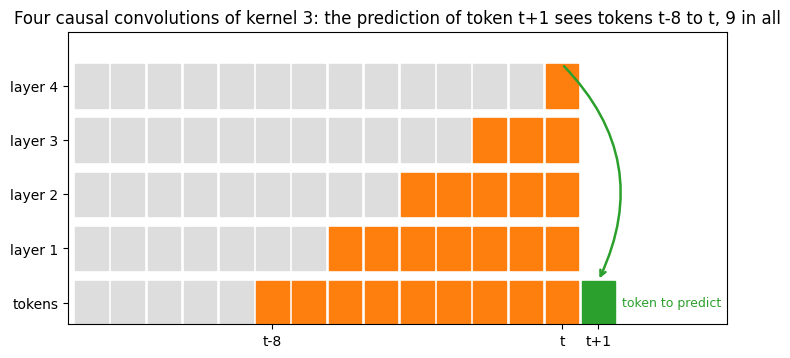

In [7]:
# Which tokens influence the prediction of the next one? (a picture of the receptive field)
layers, k, T = 4, 3, 14                      # T input tokens, positions t-13 ... t; the token to predict sits at t+1
fig, ax = plt.subplots(figsize=(8.5, 3.8))
reach = {layers: {T - 1}}                    # the output that predicts x_{t+1} is the one at position t, in the last layer
for l in range(layers, 0, -1):
    reach[l - 1] = {p - j for p in reach[l] for j in range(k) if p - j >= 0}
for l in range(layers + 1):
    for p in range(T):
        ax.add_patch(plt.Rectangle((p, l), .9, .8, color="C1" if p in reach[l] else "#dddddd"))
ax.add_patch(plt.Rectangle((T, 0), .9, .8, color="C2"))                                 # the token to predict
ax.annotate("", xy=(T + .45, .8), xytext=(T - 1 + .45, layers + .8),
            arrowprops=dict(arrowstyle="->", color="C2", lw=1.8, connectionstyle="arc3,rad=-0.35"))
ax.text(T + 1.1, .4, "token to predict", ha="left", va="center", fontsize=9, color="C2")
ax.set_xlim(-.2, T + 4); ax.set_ylim(0, layers + 1.4)
ax.set_yticks([l + .4 for l in range(layers + 1)]); ax.set_yticklabels(["tokens"] + [f"layer {l}" for l in range(1, layers + 1)])
ax.set_xticks([T - 1 - (k - 1) * layers + .45, T - 1 + .45, T + .45]); ax.set_xticklabels([f"t-{(k - 1) * layers}", "t", "t+1"])
ax.set_title(f"Four causal convolutions of kernel {k}: the prediction of token t+1 sees tokens t-{(k - 1) * layers} to t, {1 + (k - 1) * layers} in all")
plt.show()

### 4.2 The training loop, in full

Training is the same dozen lines for every model of this course. Draw a batch, compute the surprise on it (the *cross-entropy* between the model's distribution and the token that came), differentiate, take a small step against the gradient. The hyperparameters below (learning rate, batch size, dropout) were tuned beforehand on the validation set; that search is not part of this notebook.

In [8]:
def train(model, seconds, lr=2e-3, batch_size=64, window=128, log_every=250):
    """Train for a fixed wall-clock budget, evaluate on the validation set as we go, keep the best weights."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    history, best, best_state, t0, step = [], float("inf"), None, time.time(), 0
    while time.time() - t0 < seconds:
        x, y = batch("train", batch_size, window)
        logits = model(x)                                                        # (B, T, V)
        loss = F.cross_entropy(logits.reshape(-1, V), y.reshape(-1))            # surprise on this batch
        opt.zero_grad(set_to_none=True)
        loss.backward()                                                          # gradient of the surprise
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()                                                               # one small step against it
        step += 1
        if step % log_every == 0:
            val = surprise(model, "val", limit=40_000)
            history.append((step, time.time() - t0, loss.item(), val))
            if val < best:
                best, best_state = val, {k: v.detach().clone() for k, v in model.state_dict().items()}
            print(f"step {step:5d}  {time.time() - t0:4.0f}s  train loss {loss.item():.3f}  val loss {val:.3f}")
    model.load_state_dict(best_state)
    return pd.DataFrame(history, columns=["step", "seconds", "train_loss", "val_loss"])

torch.manual_seed(0)
history = train(model, seconds=120)

step   250     9s  train loss 4.724  val loss 4.885


step   500    18s  train loss 4.475  val loss 4.531


step   750    27s  train loss 4.200  val loss 4.374


step  1000    37s  train loss 4.199  val loss 4.288


step  1250    46s  train loss 3.973  val loss 4.246


...

step  2000    73s  train loss 3.918  val loss 4.157


step  2250    83s  train loss 3.878  val loss 4.148


step  2500    92s  train loss 3.893  val loss 4.150


step  2750   102s  train loss 3.871  val loss 4.124


step  3000   111s  train loss 3.872  val loss 4.115


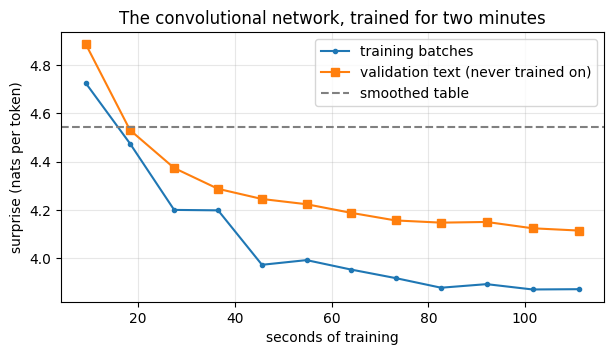

,model,loss,perplexity,bits_per_char
0,uniform guess,8.987,8000.0,3.983
1,"smoothed table, memory 2",4.545,94.1,2.014
2,local CNN (2 minutes),4.079,59.1,1.807


In [9]:
plt.figure(figsize=(7, 3.5))
plt.plot(history.seconds, history.train_loss, ".-", label="training batches")
plt.plot(history.seconds, history.val_loss, "s-", label="validation text (never trained on)")
plt.axhline(scoreboard[1]["loss"], color="gray", ls="--", label="smoothed table")
plt.xlabel("seconds of training"); plt.ylabel("surprise (nats per token)"); plt.grid(alpha=.3); plt.legend()
plt.title("The convolutional network, trained for two minutes"); plt.show()

scoreboard.append(report("local CNN (2 minutes)", surprise(model)))
pd.DataFrame(scoreboard)

Two minutes, and the network is already below the table, with a validation curve still going down. The same network trained for fifteen minutes is available as a checkpoint; from now on we use it.

In [10]:
def load_checkpoint(model, name):
    state = torch.load(fetch(f"Session2/checkpoints/{name}.pt"), map_location="cpu")
    model.load_state_dict({k: v.float() for k, v in state.items()})
    return model.to(device)

cnn = load_checkpoint(LocalCNN(), "cnn")
scoreboard.append(report("local CNN (15 minutes)", surprise(cnn)))
pd.DataFrame(scoreboard)

,model,loss,perplexity,bits_per_char
0,uniform guess,8.987,8000.0,3.983
1,"smoothed table, memory 2",4.545,94.1,2.014
2,local CNN (2 minutes),4.079,59.1,1.807
3,local CNN (15 minutes),3.944,51.6,1.748


A memory of nine tokens, three times the table's, and above all a function instead of a lookup: the regression beats the table by a wide margin, because it shares what it learns between similar contexts and never has holes.

### 4.3 The two defects of the table, revisited

Session 1 measured two things. **Coverage**: on an unseen context the table is mute; the network always answers. **Novelty**: at long memory the table recited; a network with a nine-token window cannot.

In [11]:
@torch.no_grad()
def generate(model, prompt, n=60, temperature=0.8, seed=0):
    g = torch.Generator(device="cpu").manual_seed(seed)
    ids = tok.encode(prompt).ids
    model.eval()
    for _ in range(n):
        logits = model(torch.tensor([ids[-127:]]).to(device))[0, -1] / temperature
        ids.append(torch.multinomial(torch.softmax(logits, -1).cpu(), 1, generator=g).item())
    model.train()
    return tok.decode(ids)

for seed, prompt in enumerate(["L'amour est", "Les startups de l'IA sont"]):
    print(f"{prompt!r}\n   ->", generate(cnn, prompt, seed=seed).replace("\n", " "), "\n")

"L'amour est"
   -> L'amour est composée de la lune.  La première chose a été posée par le pertian, du dix-neuvième siècle, dont tout le monde n'a plus d'air pour ne pas mettre par un cadavre à la joie de sa vieille femme.  Pendant 

"Les startups de l'IA sont"
   -> Les startups de l'IA sont de la Renaissance, de toutes les maisons de Mayence, sa respiration de la fille de Cosette.  Il aperçut, avec un silence profond du lac le long du quai.  «Les faits généraux semblent avoir le chef de leur vage, le bas-empire, 



In [12]:
# novelty, as in session 1: share of 8-token windows of generated text that occur verbatim in the training corpus
train_ids = data["train"].tolist()
seen = set(tuple(train_ids[i:i + 8]) for i in range(len(train_ids) - 8))
gen = tok.encode(" ".join(generate(cnn, "Il", n=400, seed=s) for s in range(3))).ids
copied = sum(tuple(gen[i:i + 8]) in seen for i in range(len(gen) - 8)) / (len(gen) - 8)
print(f"{copied:.1%} of the generated 8-token windows are copies of the training text")

0.6% of the generated 8-token windows are copies of the training text


`Les startups de l'IA sont` never occurs in Hugo: the table of session 1 stopped there. The network continues, in Hugo's voice, because it never memorised any context: it learned a *function* from context to next token, and a function is defined everywhere. Whether the continuation is *good* is another matter; part B is about that.

## 5. What the embeddings learned

The embedding matrix is the first thing a table cannot have: a geometry on the vocabulary. Nothing in the training signal says that `roi` and `reine` are related; the model discovers it because they are followed by the same kinds of tokens. Let us look at the nearest neighbours of a few words, and at the whole map in two dimensions.

In [13]:
E = F.normalize(cnn.emb.weight.detach().cpu(), dim=1)

def neighbours(word, k=8):
    i = tok.encode(" " + word).ids[-1]
    sims = E @ E[i]
    seen, out = {word}, []
    for j in sims.topk(k + 4).indices.tolist():                        # skip the variants of the word itself (" grand" / "grand")
        s = tok.decode([j]).strip()
        if s not in seen:
            seen.add(s); out.append(s)
    return out[:k]

for w in ["roi", "elle", "grand", "Paris", "dit", "trois"]:
    print(f"{w:8} -> {neighbours(w)}")

roi      -> ['duc', 'reine', 'comte', 'pair', 'empereur', 'baron', 'chancelier', 'marquis']
elle     -> ['Elle', 'il', 'elles', 'on', 'lui', 'Cosette', 'Fantine', 'ils']
grand    -> ['petit', 'beau', 'vieux', 'jeune', 'puissant', 'bon', 'profond', 'grands']
Paris    -> ['Rome', 'Londres', 'Voltaire', 'Mirabeau', 'Jersey', 'Mayence', '1830', 'Waterloo']
dit      -> ['disait', 'répondit', 'reprit', 'cria', 'demanda', 'ajouta', 'répliqua', 'murmura']
trois    -> ['deux', 'cinq', 'quatre', 'six', 'huit', 'douze', 'quinze', 'sept']


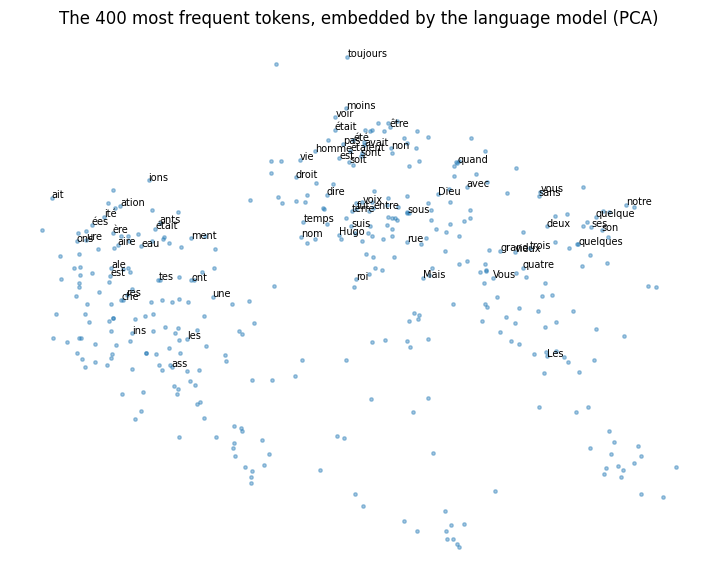

In [14]:
from sklearn.decomposition import PCA

counts = Counter(train_ids)
frequent = [i for i, _ in counts.most_common(400)]
pts = PCA(2).fit_transform(E[frequent].numpy())
plt.figure(figsize=(9, 7))
plt.scatter(pts[:, 0], pts[:, 1], s=6, alpha=.4)
for i, (px, py) in zip(frequent, pts):
    s = tok.decode([i]).strip()
    if s.isalpha() and len(s) > 2 and random.Random(i).random() < 0.35:
        plt.annotate(s, (px, py), fontsize=7)
plt.title("The 400 most frequent tokens, embedded by the language model (PCA)"); plt.axis("off"); plt.show()

Fifteen minutes of next-token prediction were enough for pronouns, determiners, verbs and numbers to gather in regions of the map. This is the phenomenon on which the whole field rests: to predict the next token, a model is forced to build a representation of the tokens it reads, and that representation captures meaning as a by-product.

## 6. How far back does the model look?

One last measurement, which will be the thread of part B. Give the model a context of $k$ tokens only, for increasing $k$, and measure its surprise on the next token. A model that uses distant context keeps improving as $k$ grows; a model that does not, flattens.

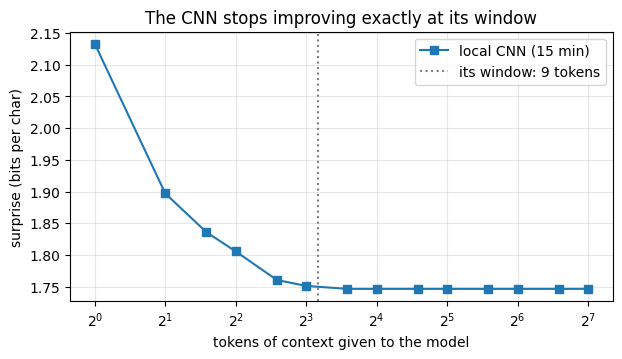

In [15]:
@torch.no_grad()
def context_curve(model, ks=(1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128), n=600, K=128):
    torch.manual_seed(1); x, y = batch("test", n, K); out = {}
    model.eval()
    for k in ks:
        nll = sum(F.cross_entropy(model(x[j:j + 200, K - k:])[:, -1], y[j:j + 200, -1], reduction="sum").item()
                  for j in range(0, n, 200))
        out[k] = nll / n / math.log(2) / chars_per_token["test"]
    model.train()
    return pd.Series(out, name="bits per char")

curve_cnn = context_curve(cnn)
plt.figure(figsize=(7, 3.5)); plt.plot(curve_cnn.index, curve_cnn.values, "s-", label="local CNN (15 min)")
plt.axvline(cnn.receptive_field, color="gray", ls=":", label=f"its window: {cnn.receptive_field} tokens")
plt.xscale("log", base=2); plt.xlabel("tokens of context given to the model"); plt.ylabel("surprise (bits per char)")
plt.grid(alpha=.3); plt.legend(); plt.title("The CNN stops improving exactly at its window"); plt.show()

The curve is flat beyond nine tokens, by construction. Yet the previous sentence often holds the clue for the next word: a name, a place, whether we are in a poem or a speech. **Part B** gives the network a memory that extends further back, measures how far it really reaches, and finds out why that is harder than it sounds.

## 7. Where this leaves us

|                | table                      | network                              |
| -------------- | -------------------------- | ------------------------------------ |
| how it answers | looks up the exact context | computes a function of the context   |
| unseen context | mute                       | always answers                       |
| long memory    | recites                    | cannot recite: the window is short   |
| what it learns | counts                     | a geometry on the vocabulary         |
| cost           | seconds to build           | minutes to train, tuning on the side |

---
*Appendix: the hyperparameters.* Learning rate, batch size, dropout and the table's mixing weight were chosen on the validation set with a search that is not part of this notebook; the notebook shows the winning values. Bengio, Ducharme, Vincent & Jauvin (2003), *A Neural Probabilistic Language Model*, is the paper behind section 4; Dauphin et al. (2017), *Language Modeling with Gated Convolutional Networks*, is the one behind the gated causal convolution.